# Figure 1G — per-residue conservation across the FRQ N-terminal region
##### Last updated 2026-07-30

This notebook builds figure panel 1G, which highlights per-residue conservation and phophosite location across the FRQ NTD.

Conservation is calculated from a pre-built multiple sequence alignment of FRQ orthologs (`aligned.fasta`), using *N. crassa* FRQ (UniProt P19970) as the target sequence. We use the property-entropy metric, which scores each column by the entropy over amino acid chemical classes rather than over the twenty amino acids individually, so conservative substitutions are not penalised as heavily as they would be under a straight identity or Shannon-entropy measure. Scores are normalised to run from 0 (unconstrained) to 1 (invariant). Scores are reported against the ungapped target sequence, so position *i* on the x-axis is residue *i* of P19970.

Because the conservation calculation is the slow step, it is cached to `per_res_cons.npy`. As of right now, if you set `RECOMPUTE_PER_RESIDUE_CONSERVATION = True` you require our local implementation of the Capra-Singh Property Entropy (PE) calculation, which reproduces code in the 2007 Capra & Singh paper. Note this functionallity will be coming to sparrow soon.

The original alignment of the sequences (shared here) was generated using clustal omega on default settings.

**Dependencies:**

* Numpy
* Matplotlib
* [protfasta](https://protfasta.readthedocs.io/en/latest/)

**Inputs:** `aligned.fasta` (FRQ ortholog alignment), `per_res_cons.npy` (cached conservation scores)

**Output:** `figure_1g.pdf`


In [11]:
import numpy as np
import matplotlib
import protfasta

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
	
# Set such that PDF fonts export in a manner that they
# are editable in illustrator/affinity
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# set to define axes linewidths
matplotlib.rcParams['axes.linewidth'] = 0.5

# this defines some prefactors so inline figures look nice
# on a retina macbook. These can be commented out without any
# issue and are solely asthetic.
%matplotlib inline
%config InlineBackend.figure_format='retina'

# UPDATE 2026-07-30 (Arial for this figure)
font = {'family' : 'Arial',
    	'weight' : 'normal'}

matplotlib.rc('font', **font)


In [12]:
# do not set to True...
RECOMPUTE_PER_RESIDUE_CONSERVATION = False

In [13]:
# read in
wt_id = 'sp|P19970|FRQ_NEUCR Frequency clock protein OS=Neurospora crassa (strain ATCC 24698 / 74-OR23-1A / CBS 708.71 / DSM 1257 / FGSC 987) OX=367110 GN=f'
al = protfasta.read_fasta('aligned.fasta', alignment=True)

In [14]:
if RECOMPUTE_PER_RESIDUE_CONSERVATION:
    from housetools.sequence_tools import sequence_conservation

    C = sequence_conservation.ConservationCalculator()
    b = C.calculate_conservation(al, target=wt_id, mode='property entropy', gap_cutoff=0.99)
    np.save('per_res_cons.npy', b.target_normalized_scores)

    normalized_scores = b.target_normalized_scores
    target_sequence = b.target_sequence
else:
    normalized_scores = np.load('per_res_cons.npy')
    _tmp_seq = al[wt_id]
    target_sequence = _tmp_seq.replace('-', '')

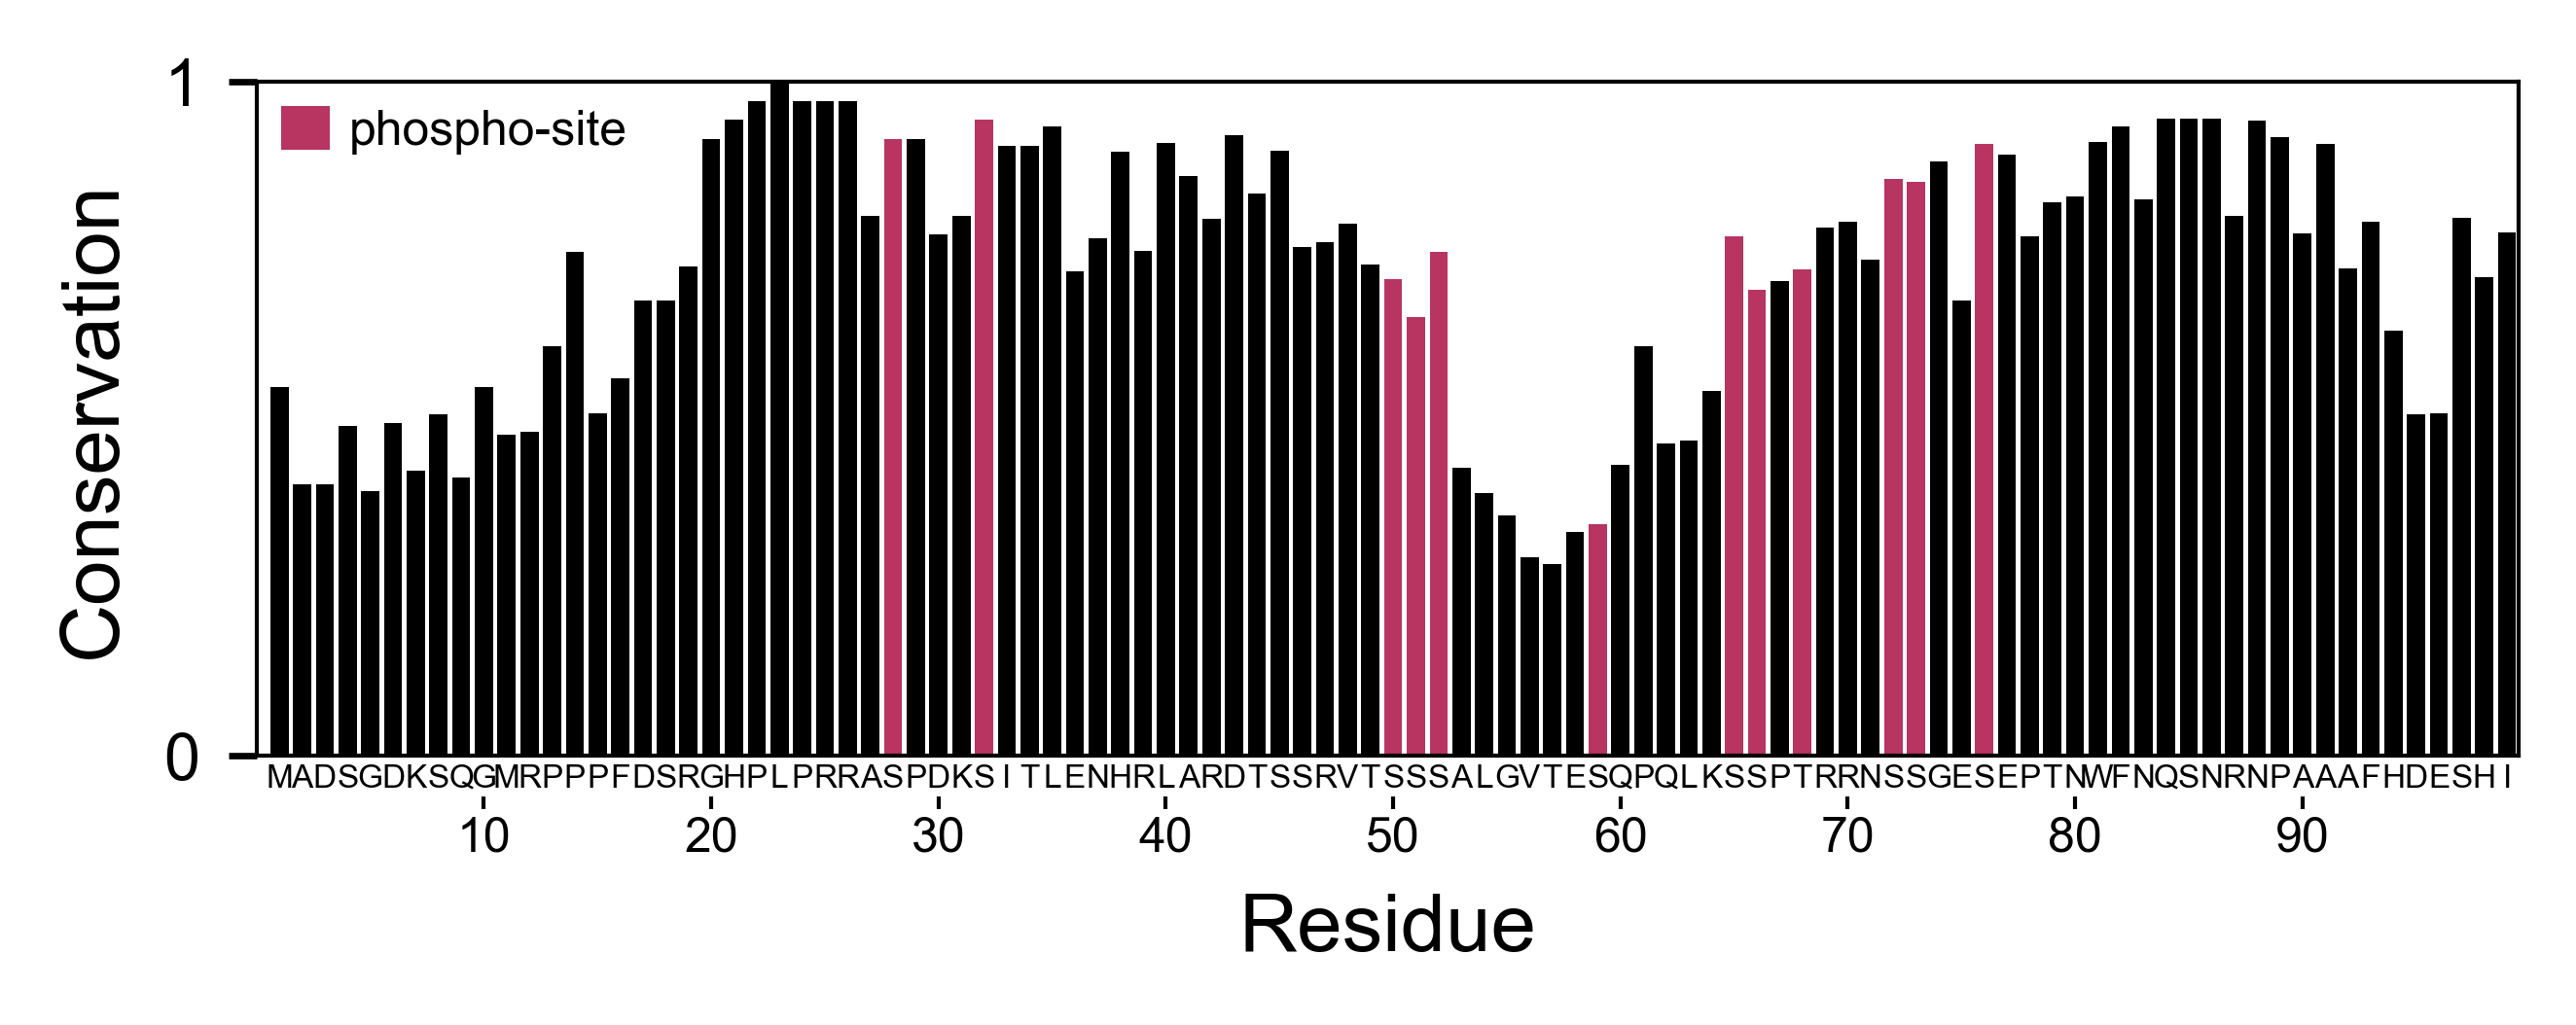

In [15]:
from matplotlib.patches import Patch

figure(num=None, figsize=(5, 1.5), dpi=300, facecolor='w', edgecolor='k')
ax = plt.gca()

# residue positions (1-indexed)
positions = np.arange(1, len(target_sequence)+1)

# highlight specific residues
highlight = [28, 32, 50, 51, 52, 59, 65,66,68, 72,73,76]
bar_colors = ['#b73560' if p in highlight else 'k' for p in positions]

plt.bar(positions, normalized_scores, color=bar_colors, linewidth=0.5)
plt.ylim([0,1])

plt.ylabel('Conservation',fontsize=10)
plt.yticks([0,1], fontsize=8)

# every residue gets its one-letter code on the primary x-axis, tucked right
# up against the bars
ax.set_xticks(positions)
ax.set_xticklabels(list(target_sequence), fontsize=4)
ax.tick_params(axis='x', length=0, pad=1)

# residue numbers every 10 sit on a second axis just below the sequence, so
# that they don't displace any of the one-letter codes
numbered = positions[positions % 10 == 0]
sec = ax.secondary_xaxis(-0.06)
sec.set_xticks(numbered)
sec.set_xticklabels(numbered, fontsize=6)
sec.tick_params(length=1.5, width=0.5, pad=1)
sec.spines['bottom'].set_visible(False)
sec.set_xlabel('Residue', fontsize=10)

# colour key for the highlighted residues
ax.legend(handles=[Patch(facecolor='#b73560', label='phospho-site')],
          loc='upper left', fontsize=6, frameon=False, handlelength=1.0,
          handleheight=1.0, handletextpad=0.4, borderpad=0.2, borderaxespad=0.3)

plt.xlim([0,99.5])
plt.savefig('figure_1g.pdf', bbox_inches='tight')